In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from src.config import *

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [36]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

/Users/apple/dev/EvoFinGraph


In [4]:
features = pd.read_csv(FEATURE_FILE, header=None)
classes = pd.read_csv(CLASS_FILE)
edges = pd.read_csv(EDGE_FILE)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(f"Features Shape : {features.shape}")
print(f"Classes Shape  : {classes.shape}")
print(f"Edges Shape    : {edges.shape}")

DATASET LOADED SUCCESSFULLY
Features Shape : (203769, 167)
Classes Shape  : (203769, 2)
Edges Shape    : (234355, 2)


In [5]:
feature_columns = (
    ["txId", "time_step"]
    + [f"feature_{i}" for i in range(165)]
)

features.columns = feature_columns

features.head()

,txId,time_step,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-

In [6]:
print("FEATURES")
display(features.head())

print("\nCLASSES")
display(classes.head())

print("\nEDGES")
display(edges.head())

FEATURES


,txId,time_step,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-


CLASSES


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown



EDGES


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


In [7]:
df = features.merge(classes, on="txId")

print(df.shape)

df.head()

(203769, 168)


,txId,time_step,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.2272

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 168 entries, txId to class
dtypes: float64(165), int64(2), str(1)
memory usage: 261.2 MB


In [9]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing

Series([], dtype: int64)

In [10]:
classes["class"].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

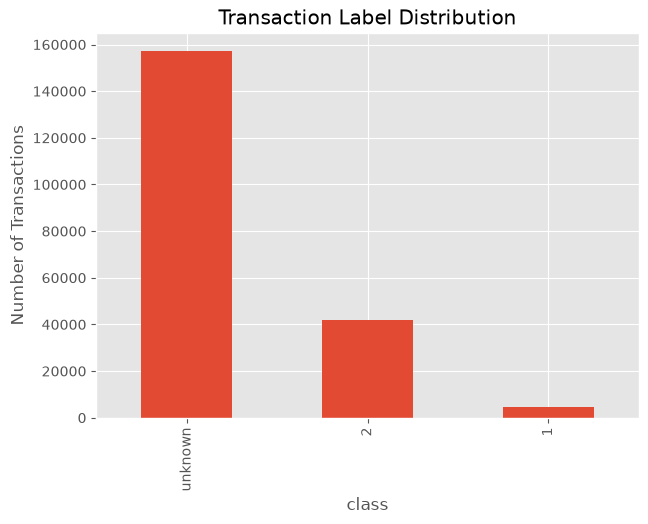

In [11]:
classes["class"].value_counts().plot(
    kind="bar",
    figsize=(7,5),
    title="Transaction Label Distribution"
)

plt.ylabel("Number of Transactions")
plt.show()

Figure 2

Distribution of licit, illicit and unlabeled transactions.

In [12]:
distribution = (
    classes["class"]
    .value_counts(normalize=True)
    * 100
)

distribution

class
unknown    77.148634
2          20.620899
1           2.230467
Name: proportion, dtype: float64

severe class imbalance

In [13]:
transactions_per_step = (
    features
    .groupby("time_step")
    .size()
)

transactions_per_step.head()

time_step
1    7880
2    4544
3    6621
4    5693
5    6803
dtype: int64

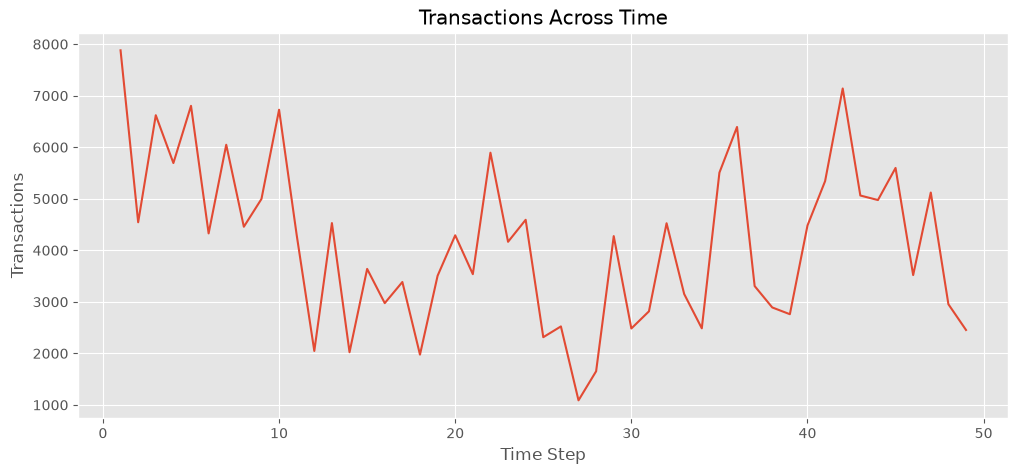

In [14]:
plt.figure(figsize=(12,5))

transactions_per_step.plot()

plt.xlabel("Time Step")
plt.ylabel("Transactions")
plt.title("Transactions Across Time")

plt.show()

This tells us whether fraud activity changes over time.

In [15]:
merged = features.merge(classes,on="txId")

In [16]:
fraud = merged[
    merged["class"]=="1"
]

In [17]:
fraud.groupby("time_step").size()

time_step
1      17
2      18
3      11
4      30
5       8
6       5
7     102
8      67
9     248
10     18
11    131
12     16
13    291
14     43
15    147
16    128
17     99
18     52
19     80
20    260
21    100
22    158
23     53
24    137
25    118
26     96
27     24
28     85
29    329
30     83
31    106
32    342
33     23
34     37
35    182
36     33
37     40
38    111
39     81
40    112
41    116
42    239
43     24
44     24
45      5
46      2
47     22
48     36
49     56
dtype: int64

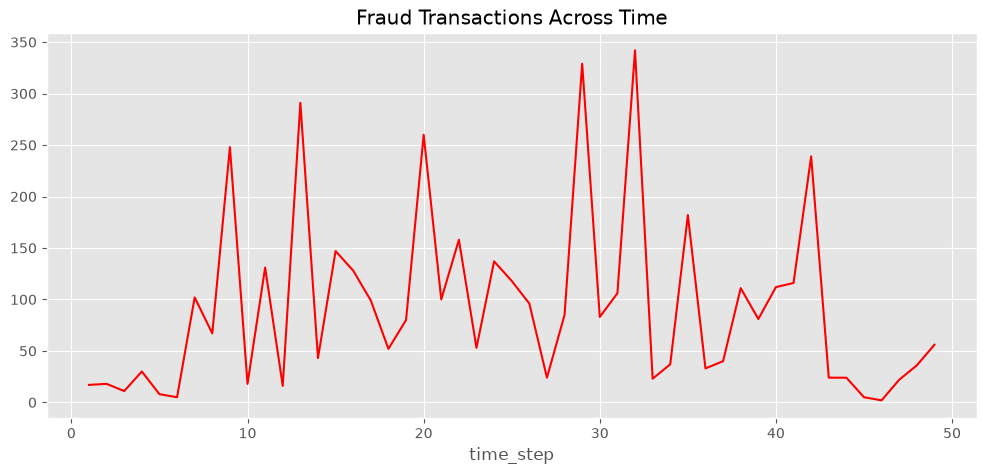

In [18]:
fraud.groupby("time_step").size().plot(
    figsize=(12,5),
    color="red"
)

plt.title("Fraud Transactions Across Time")

plt.show()

Our novelty is evolution over time
This graph is the first evidence

In [19]:
G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

In [20]:
degrees = [d for _,d in G.degree()]

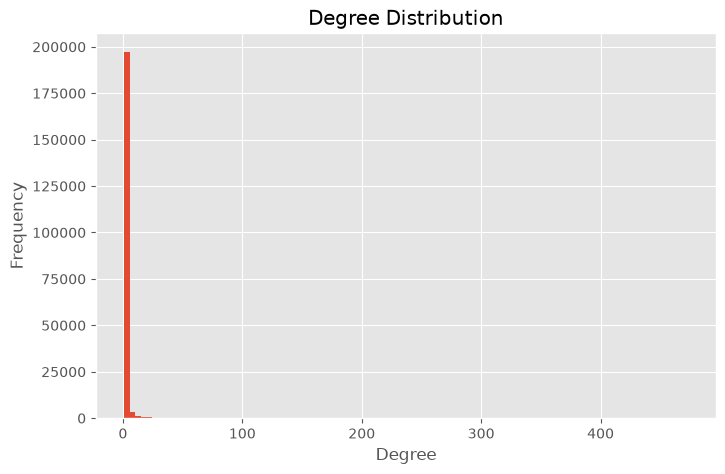

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    degrees,
    bins=100
)

plt.xlabel("Degree")

plt.ylabel("Frequency")

plt.title("Degree Distribution")

plt.show()

Bitcoin networks are usually power law which motivates graph learning.

In [22]:
print("Nodes :", G.number_of_nodes())
print("Edges :", G.number_of_edges())

print(
    "Average Degree :",
    np.mean(degrees)
)

Nodes : 203769
Edges : 234355
Average Degree : 2.3002026804862368


Table 1 in the paper.

In [23]:
components = list(
    nx.weakly_connected_components(G)
)

print(
    len(components)
)

49


Interesting observation

Bitcoin is NOT one giant graph.
It has many disconnected components.Useful for community detection

In [26]:
from src.config import METRIC_DIR

METRIC_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame({
    "num_transactions": [len(features)],
    "num_edges": [len(edges)],
    "num_nodes": [G.number_of_nodes()],
    "num_time_steps": [features["time_step"].nunique()],
    "avg_degree": [np.mean(degrees)],
    "connected_components": [len(components)]
})

summary.to_csv(
    METRIC_DIR / "dataset_summary.csv",
    index=False
)

print(summary)

   num_transactions  num_edges  num_nodes  num_time_steps  avg_degree  \
0            203769     234355     203769              49    2.300203   

   connected_components  
0                    49  


In [ ]:
"""test cell for checking the loader.py"""
from src.data.loader import load_dataset

features, classes, edges = load_dataset()

print(features.head())
print(classes.head())
print(edges.head())

        txId  time_step  feature_0  feature_1  feature_2  feature_3  \
0  230425980          1  -0.171469  -0.184668  -1.201369  -0.121970   
1    5530458          1  -0.171484  -0.184668  -1.201369  -0.121970   
2  232022460          1  -0.172107  -0.184668  -1.201369  -0.121970   
3  232438397          1   0.163054   1.963790  -0.646376  12.409294   
4  230460314          1   1.011523  -0.081127  -1.201369   1.153668   

   feature_4  feature_5  feature_6  feature_7  feature_8  feature_9  \
0  -0.043875  -0.113002  -0.061584  -0.162097  -0.167933  -0.049707   
1  -0.043875  -0.113002  -0.061584  -0.162112  -0.167948  -0.049707   
2  -0.043875  -0.113002  -0.061584  -0.162749  -0.168576  -0.049707   
3  -0.063725   9.782742  12.414558  -0.163645  -0.115831   0.043598   
4   0.333276   1.312656  -0.061584  -0.163523   0.041399   0.935886   

   feature_10  feature_11  feature_12  feature_13  feature_14  feature_15  \
0   -0.164402   -0.028741   -0.035391   -0.042955   -0.013282   -0.05

In [ ]:
"""test for validator.py"""
from src.data.validator import DataValidator

DataValidator.check_duplicates(features, "txId")

DataValidator.check_missing(features)

DataValidator.check_unique_labels(classes)

DataValidator.check_time_steps(features)

Duplicate txId: 0
Missing Values: 0
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
Time Steps: 49


In [29]:
"""test for preprocessing.py"""
from src.data.preprocessing import DataPreprocessor

processor = DataPreprocessor()

processed = processor.run()

processed.head()

,txId,time_step,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,feature_57,feature_58,feature_59,feature_60,feature_61,feature_62,feature_63,feature_64,feature_65,feature_66,feature_67,feature_68,feature_69,feature_70,feature_71,feature_72,feature_73,feature_74,feature_75,feature_76,feature_77,feature_78,feature_79,feature_80,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90,feature_91,feature_92,feature_93,feature_94,feature_95,feature_96,feature_97,feature_98,feature_99,feature_100,feature_101,feature_102,feature_103,feature_104,feature_105,feature_106,feature_107,feature_108,feature_109,feature_110,feature_111,feature_112,feature_113,feature_114,feature_115,feature_116,feature_117,feature_118,feature_119,feature_120,feature_121,feature_122,feature_123,feature_124,feature_125,feature_126,feature_127,feature_128,feature_129,feature_130,feature_131,feature_132,feature_133,feature_134,feature_135,feature_136,feature_137,feature_138,feature_139,feature_140,feature_141,feature_142,feature_143,feature_144,feature_145,feature_146,feature_147,feature_148,feature_149,feature_150,feature_151,feature_152,feature_153,feature_154,feature_155,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,class
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,-0.115831,0.043598,-0.163905,1.059993,2.397457,-0.063200,-0.013282,4.800240,0.174329,-0.172908,0.619399,-0.243300,-0.243452,-0.139732,-0.146895,-0.079667,-0.155554,0.773847,0.378516,-0.139734,-0.146891,-0.079667,-0.155553,0.773932,0.378593,-0.024669,-0.031271,-0.023044,-0.026215,0.101008,0.026315,-0.227215,-0.156772,0.089307,-0.212195,-2.772015,-2.371969,-0.227203,-0.221151,-0.066858,-0.232011,-2.165534,-2.175855,-0.414008,4.181192,4.346640,1.777963,-1.451545,-1.530250,4.628683,0.513804,-0.163126,1.208220,-0.196435,-0.196189,4.629650,0.513869,-0.163115,1.208278,-0.196409,-0.196133,-0.017032,-0.030026,-0.01764,-0.015071,-0.140763,-0.140335,4.313295,0.216750,-0.250574,0.707151,-0.169119,-0.167165,6.220011,0.216948,-0.255168,0.717108,-0.187191,-0.185274,3.991587,0.810879,-0.694235,2.084651,0.025308,0.025217,-0.171098,0.266450,0.159432,-0.159946,0.970465,1.928382,-1.457953,-1.493992,-0.083124,-1.485957,-0.234171,-0.205513,-0.176219,-0.056011,-0.082822,-0.191696,0.323773,0.668621,-1.096336,0.787435,0.856163,-1.104530,0.715115,0.958373,-0.116425,0.312047,0.064623,-0.101755,-0.247676,-1.201993,-0.095559,0.523326,0.019771,-0.119195,0.147881,0.956170,0.759756,-0.041556,-0.188716,0.149949,-0.047722,-0.048171,-1.373723,-1.356131,-0.301754,-1.404445,0.183133,0.182748,-0.163577,-0.456561,-0.424672,-0.436915,0.143001,0.142525,-0.425896,-1.421138,-1.059868,-1.071885,0.185597,0.185492,-0.216814,-0.617907,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0
9,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,-0.144554,0.020069,-0.163135,1.696691,2.414968,-0.063200,-0.013282,2.370512,0.001525,-0.172908,0.221419,-0.243300,-0.243452,-0.139732,-0.147416,-0.079747,-0.155559,0.665165,1.037078,-0.139734,-0.147411,-0.079746,-0.155559,0.665251,1.037113,-0.024669,-0.031272,-0.023045,-0.026215,-0.973502,-0.973372,-0.227159,-0.156772,0.020778,-0.227569,-1.618971,-1.516593,-0.227144,-0.233499,-0.077441,-0.233665,-1.452326,-1.486171

In [30]:
processed["class"].value_counts()

class
0    42019
1     4545
Name: count, dtype: int64

DAY 2 - building graphs for one snapshot test

In [32]:
from src.graph.builder import TemporalGraphBuilder

builder = TemporalGraphBuilder()

G = builder.build_snapshot(20)

print(G)

DiGraph with 900 nodes and 0 edges


In [33]:
len(G.nodes)

900

INSPECTING ONE NODE

In [34]:
node = list(G.nodes())[0]

G.nodes[node]

{'label': np.float64(0.0),
 'timestep': np.float64(20.0),
 'features': array([-0.17203984,  0.93356565, -0.09138345,  4.15516838, -0.04387455,
         3.57693649,  0.24271234, -0.16364521, -0.16868463, -0.04839205,
        -0.1659324 ,  0.63094145,  2.41400531, -0.0429553 , -0.01328161,
        -0.05251233, -0.17052874, -0.17259332, -0.17514801,  0.88705787,
         0.88455653, -0.13973186, -0.04025147, -0.05126814, -0.15316482,
         0.59769528,  1.65113477, -0.13973366, -0.04023953, -0.05126763,
        -0.15316452,  0.5977823 ,  1.65113037, -0.02466883, -0.03127097,
        -0.02304367, -0.02621462, -1.14757025, -0.18360513, -0.22720599,
         0.8351729 ,  0.59142966, -0.21488731,  0.90466207,  2.1080308 ,
        -0.22719348,  0.32920799,  0.44292184, -0.225085  ,  0.91885592,
         2.08257608, -0.39192924,  2.40298603,  2.12224136,  0.6660601 ,
         0.84799233,  0.81788927, -0.03909367, -0.07282871, -0.05658159,
        -0.06116722,  0.92347298,  0.92301071, -0.0390